# Retail Customer Analytics

## Project Overview

This project explores transactional data from an online retail business to better understand customer behaviour, product performance, and sales trends.

The analysis combines SQL for querying transactional data with Python for data analysis and visualization. The objective is to answer practical business questions and present the findings in a clear and accessible way.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [8]:
df = pd.read_csv("../data/processed/online_retail_cleaned.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8


## Dataset Overview

The dataset contains transactional records from an online retail business.

Each row represents a product purchased within an invoice and includes information such as:

- Invoice number
- Product description
- Quantity
- Unit price
- Customer ID
- Country
- Revenue

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536641 entries, 0 to 536640
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  str    
 1   StockCode    536641 non-null  str    
 2   Description  535187 non-null  str    
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  str    
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  str    
 8   Revenue      536641 non-null  float64
 9   Month        536641 non-null  int64  
 10  Day          536641 non-null  str    
 11  Hour         536641 non-null  int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 49.1 MB


In [37]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday,8,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010-12


In [38]:
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset contains 536,641 rows and 13 columns.


In [15]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 536,641
Columns: 12


## Data Cleaning Summary

Before starting the analysis, the dataset was cleaned to improve data quality and ensure reliable results.

The following preprocessing steps were performed:

- Removed cancelled transactions.
- Removed rows with missing product descriptions.
- Filtered records with non-positive quantities and unit prices.
- Created a Revenue column by multiplying Quantity and UnitPrice.
- Converted InvoiceDate to datetime format for time-based analysis.

## Exploratory Data Analysis



In [39]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
Month               0
Day                 0
Hour                0
YearMonth           0
dtype: int64

In [40]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
Revenue         5998
Month             12
Day                6
Hour              15
YearMonth         13
dtype: int64

In [41]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Month,Hour
count,536641.000000,536641,536641.000000,401604.000000,536641.000000,536641.000000,536641.000000
mean,9.620029,2011-07-04 08:57:06.087421,4.632656,15281.160818,18.123861,7.544820,13.077154
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000,1.000000,6.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.000000,3.750000,5.000000,11.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.000000,9.870000,8.000000,13.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.000000,17.400000,11.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,12.000000,20.000000
std,219.130156,NaN,97.233118,1714.006089,380.656263,3.508696,2.447505


### Initial Observations

Most fields are complete after preprocessing. Customer IDs still contain some missing values, which represent guest purchases rather than data quality issues.

The Revenue column created during preprocessing is used throughout the analysis to evaluate customer and product performance.

In [16]:
# Revenue by Country

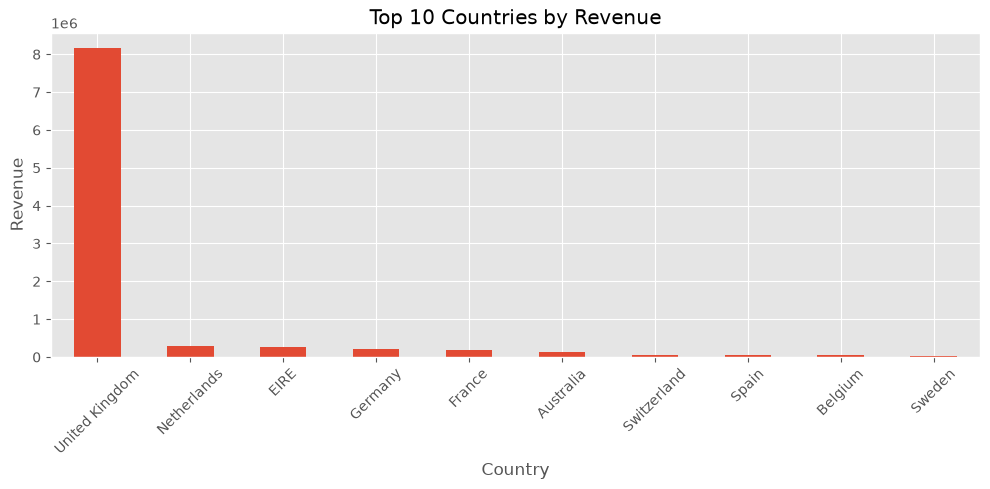

In [17]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

The United Kingdom generates the highest revenue by a considerable margin. The remaining countries contribute much smaller shares, indicating that sales are heavily concentrated in one market.

This suggests there may be opportunities to expand revenue in international markets while continuing to maintain the strong domestic customer base.

In [42]:
country_revenue

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

# Top 10 Customers by Revenue

### Business Question

Who are the highest-value customers based on total revenue generated?

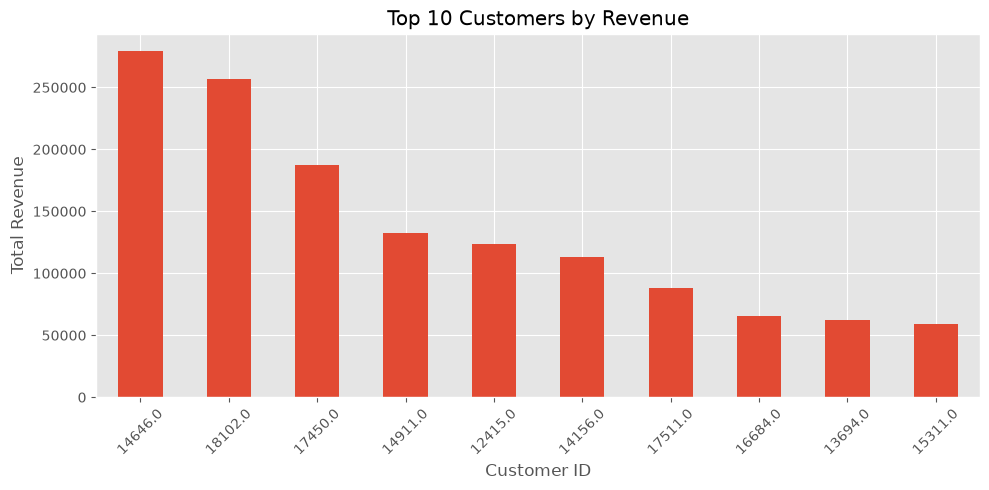

In [19]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
top_customers

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

### Business Insight

Revenue is concentrated among a relatively small number of customers. The highest-spending customers contribute significantly more revenue than the rest of the top 10.

This suggests that retaining these customers should be a priority, as losing even a few of them could have a noticeable impact on overall sales.

# Top Products by Revenue

### Business Question

Which products generate the highest revenue?

In [36]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

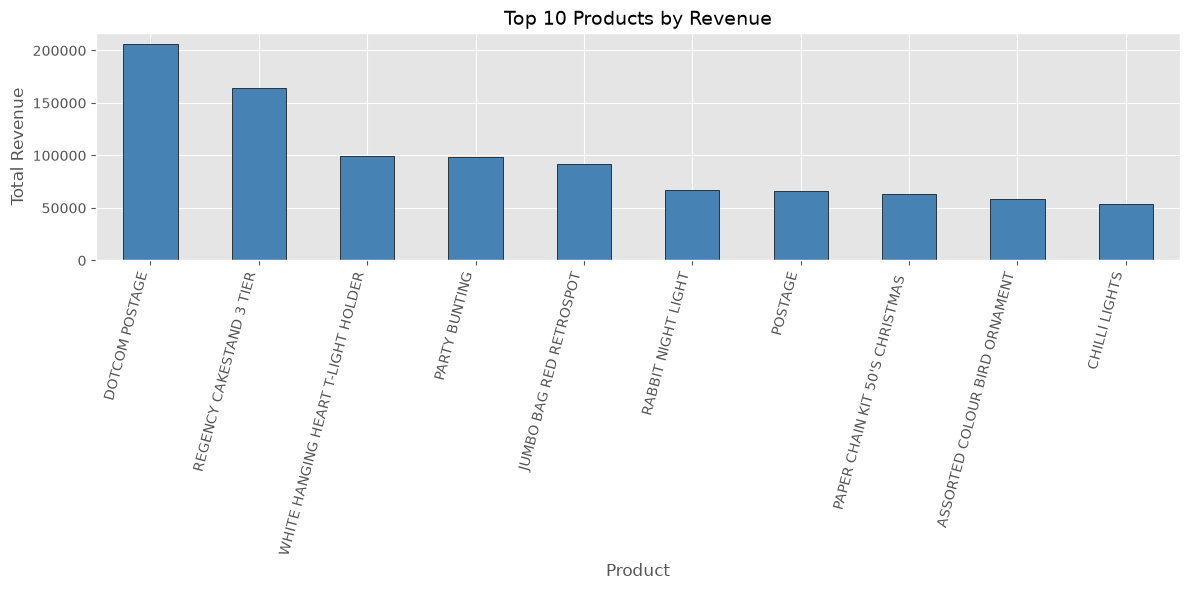

In [23]:
plt.figure(figsize=(12, 6))

top_products.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

### Business Insight

A relatively small number of products account for a large share of the total revenue.

These products are likely key drivers of sales and should remain well stocked. They may also be good candidates for promotional campaigns or product bundles.

# Top Products by Quantity Sold

### Business Question

Which products sold the highest number of units?

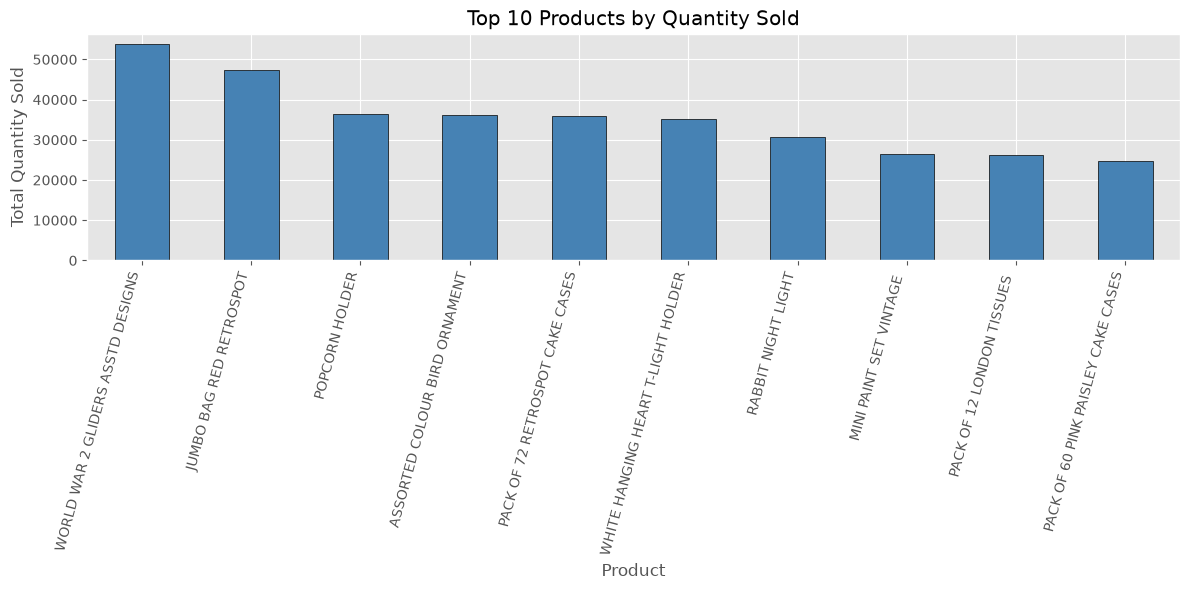

In [24]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

top_quantity.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

In [25]:
top_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

### Business Insight

The products with the highest sales volume are not always the products generating the highest revenue.

This highlights the difference between products that sell frequently and products that contribute the most financially. Looking at both metrics together provides a better understanding of product performance.

# Customer Segmentation

### Business Question

How are customers distributed across different spending categories?

In [26]:
customer_spending = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .reset_index(name="TotalSpent")
)

customer_spending.head()

,CustomerID,TotalSpent
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [27]:
def customer_category(total):
    if total >= 10000:
        return "VIP"
    elif total >= 5000:
        return "Gold"
    elif total >= 1000:
        return "Silver"
    else:
        return "Bronze"


customer_spending["Category"] = customer_spending["TotalSpent"].apply(customer_category)

customer_spending.head()

,CustomerID,TotalSpent,Category
0,12346.0,0.00,Bronze
1,12347.0,4310.00,Silver
2,12348.0,1797.24,Silver
3,12349.0,1757.55,Silver
4,12350.0,334.40,Bronze


In [28]:
category_counts = (
    customer_spending["Category"]
    .value_counts()
)

category_counts

Category
Bronze    2742
Silver    1368
Gold       165
VIP         97
Name: count, dtype: int64

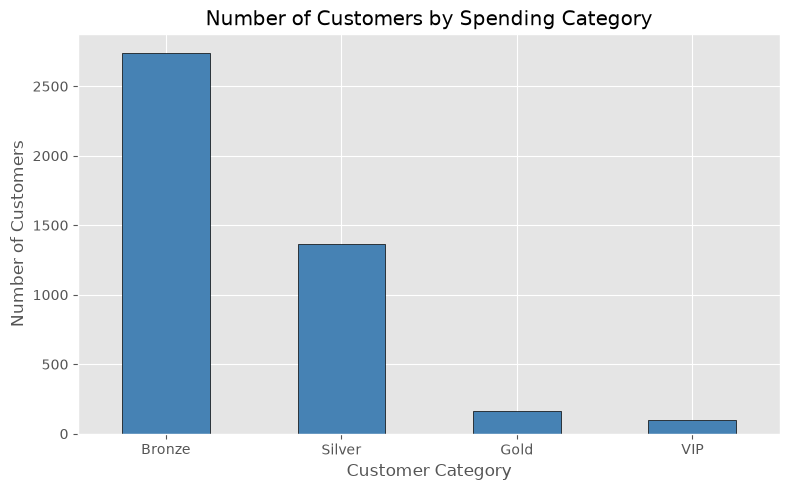

In [30]:
plt.figure(figsize=(8,5))

category_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Number of Customers by Spending Category")
plt.xlabel("Customer Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight

Most customers fall into the Bronze category, while only a small percentage qualify as VIP customers.

Although VIP customers represent a smaller group, they are likely responsible for a significant share of the total revenue. This makes customer retention an important business consideration.

# Monthly Revenue Trend

### Business Question

How does total revenue change over time?

In [31]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Extract Year-Month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [32]:
monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
)

monthly_revenue.head()

YearMonth
2010-12    746723.610
2011-01    558448.560
2011-02    497026.410
2011-03    682013.980
2011-04    492367.841
Freq: M, Name: Revenue, dtype: float64

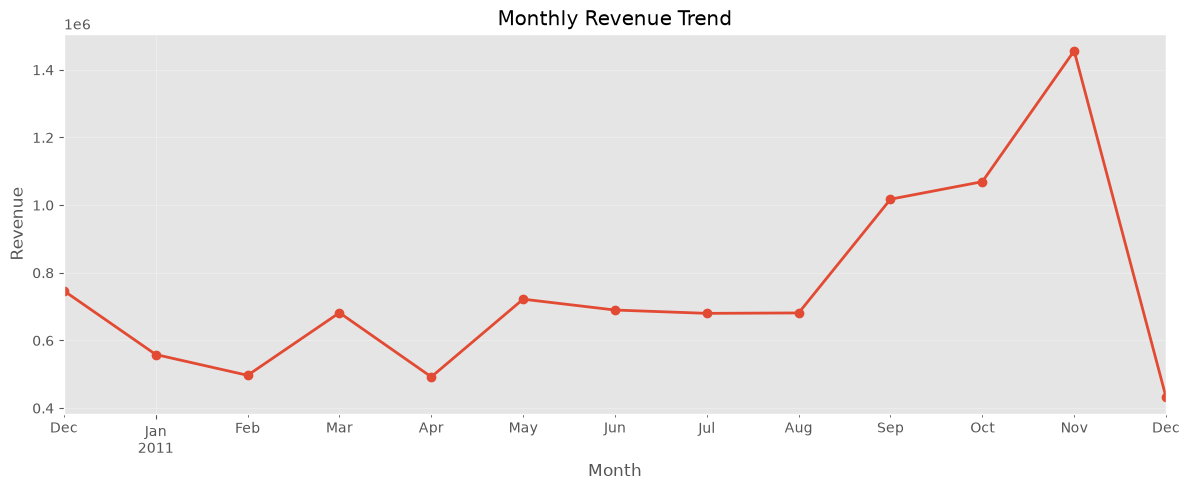

In [33]:
plt.figure(figsize=(12,5))

monthly_revenue.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

Revenue varies throughout the year rather than remaining constant.

Looking at the monthly trend makes it easier to identify periods of strong and weak sales. This type of analysis can help businesses plan inventory, staffing, and marketing activities around expected demand.

# Customer Ranking

### Business Question

Who are the highest-value customers based on total spending?

In [43]:
customer_rank = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .reset_index(name="TotalSpent")
)

customer_rank["Rank"] = (
    customer_rank["TotalSpent"]
    .rank(method="dense", ascending=False)
)

customer_rank = customer_rank.sort_values("Rank")

top_ranked = customer_rank.head(10)

top_ranked

,CustomerID,TotalSpent,Rank
1703,14646.0,279489.02,1.0
4233,18102.0,256438.49,2.0
3758,17450.0,187322.17,3.0
1895,14911.0,132458.73,4.0
55,12415.0,123725.45,5.0
1345,14156.0,113214.59,6.0
3801,17511.0,88125.38,7.0
3202,16684.0,65892.08,8.0
1005,13694.0,62690.54,9.0
2192,15311.0,59284.19,10.0


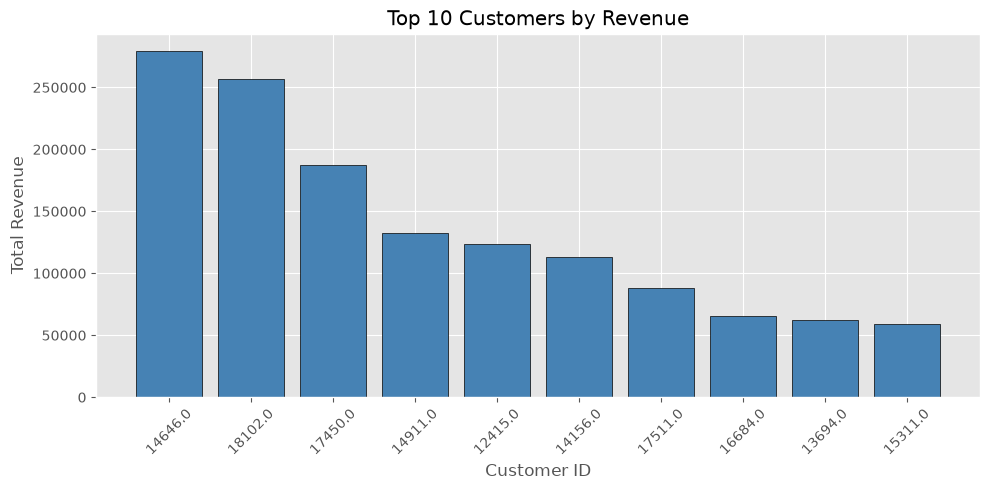

In [35]:
top_ranked = customer_rank.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_ranked["CustomerID"].astype(str),
    top_ranked["TotalSpent"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

The highest-ranked customers contribute substantially more revenue than the average customer.

Understanding who these customers are allows the business to focus retention efforts where they are likely to have the greatest impact.

# Key Findings

- The United Kingdom accounts for the largest share of total revenue.
- A relatively small group of customers contributes a significant portion of overall sales.
- High-selling products by quantity are not always the highest revenue-generating products.
- Most customers belong to the Bronze spending category, while VIP customers represent only a small percentage of the customer base.
- Revenue changes throughout the year, highlighting the importance of monitoring sales trends over time.

# Conclusion

This project explored transactional retail data to answer practical business questions using SQL and Python.

The analysis identified patterns in customer spending, product performance, and revenue trends. The findings could support marketing, inventory planning, and customer retention initiatives.

Future work could extend this analysis through predictive modelling and interactive business dashboards.

# Next Steps

This analysis focused on understanding historical customer transactions.

Possible future improvements include:

- Building customer lifetime value (CLV) models.
- Predicting customer churn using machine learning.
- Forecasting future sales trends.
- Developing an interactive dashboard for real-time business monitoring.